In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os, glob
from scipy import ndimage, misc
import math

In [3]:
os.getcwd()

'C:\\Users\\Handwriting\\Desktop\\Dheeraj\\HEMI\\Python_Scripts'

In [4]:
path=r'C:\Users\Handwriting\Desktop\Dheeraj\HEMI\Main_Files\Crack_speed_evaluation\090920b_S1_IP02_07_04_2022\TIFF16\PBC_NFC_090920b_S1_IP_02_100mm_36psi_PS' 

In [5]:
img_list=os.listdir(path)

In [6]:
# Mask Image:
mask_img= cv2.imread(path+ "\\"+ img_list[200])

In [7]:
import imutils
def is_contour_bad(c):
    # approximate the contour
    area = cv2.contourArea(c) 
    # the contour is 'bad' if it is not a rectangle
    return not area >= 400

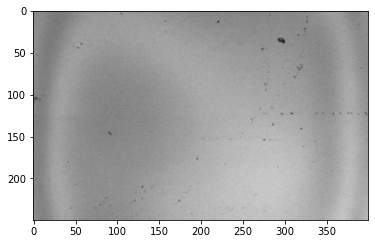

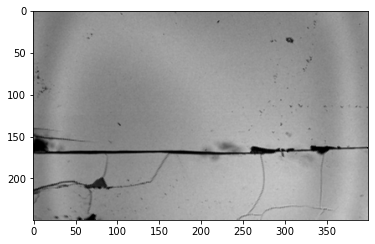

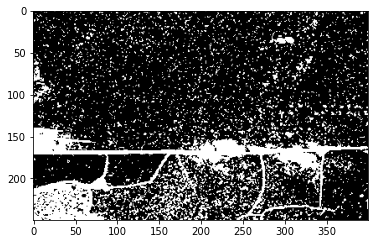

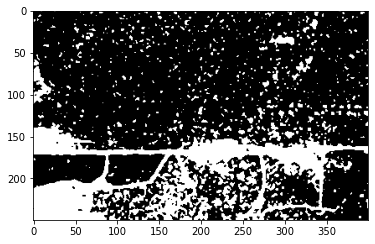

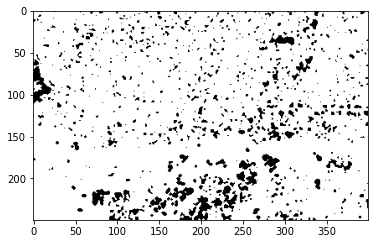

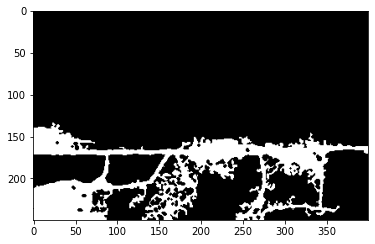

Left most point: (0, 140) Right most point: (399, 170)


In [11]:
#########################
# Initializing Target Image
target_image = cv2.imread(path+ "\\"+ img_list[220])
plt.imshow(mask_img, cmap='gray')
plt.show()
plt.imshow(target_image, cmap='gray')
plt.show()
##########################
#Subtracting Mask Image and Target Image:
sub_img= cv2.absdiff(mask_img, target_image)
plt.imshow(sub_img, cmap='gray')
##########################
#Thresholding The Subtracted Image (BINARY):
ret,thresh = cv2.threshold(sub_img,7,255,cv2.THRESH_BINARY)
plt.imshow(thresh,'gray',vmin=0,vmax=255)
##########################
# Applying Gaussian Blur to the Thresholded Image:
blur = cv2.GaussianBlur(thresh,(5,5),0)
thresh1 = cv2.threshold(blur, 80, 255, cv2.THRESH_BINARY)[1]
plt.imshow(thresh)
plt.show()
plt.imshow(thresh1)
plt.show()
#############################
# Converting Binary to Gray:
gray1 = cv2.cvtColor(thresh1, cv2.COLOR_BGR2GRAY)
plt.imshow(gray1)
###############################
#Getting the CONTOURS of the blobs:
contours, hierarchy = cv2.findContours(gray1, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
##############################
#Creating mask and removing unwanted contours:
mask = np.ones(gray1.shape[:2], dtype="uint8") * 255
# loop over the contours
for c in contours:
    # if the contour is bad, draw it on the mask
    if is_contour_bad(c):
        cv2.drawContours(mask, [c], -1, 0, -1)
# remove the contours from the image and show the resulting images
newImage = cv2.bitwise_and(gray1, mask)
plt.imshow(mask, cmap='gray')
plt.show()
plt.imshow(newImage, cmap='gray')
plt.show()
cv2.waitKey(0)
##############################
## Finding Extreme Point:
cnts = cv2.findContours(newImage.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
c = max(cnts, key=cv2.contourArea)
# determine the most extreme points along the contour
extLeft = tuple(c[c[:, :, 0].argmin()][0])
extRight = tuple(c[c[:, :, 0].argmax()][0])
print('Left most point:',extLeft,'Right most point:',extRight)

# Cracks Coordinates:

### Crack Starting from left:
#### 1.(399,173)
#### 2.(273,178)
#### 3.(172,176)
#### 4.(78,178)
#### 5.(0,176)

In [3]:
my_coordinates= [(399,173),(273,178),(172,176),(78,178),(0,176)]

In [4]:
def distance(p0, p1):
    return math.sqrt((p0[0] - p1[0])**2 + (p0[1] - p1[1])**2)

In [5]:
distance_list=[]
for i in range(1,len(my_coordinates)):
#     print(my_coordinates[i])
    d= distance(my_coordinates[i-1], my_coordinates[i])
    print(d)
    distance_list.append(d)

126.09916732476864
101.01980003939822
94.02127418834527
78.02563681252464


In [6]:
distance_list############   Need to change the Scale of distances!

[126.09916732476864, 101.01980003939822, 94.02127418834527, 78.02563681252464]

In [7]:
# Converting pixels to mm:
# 310 pixels= 1 mm
# There fore 1 pixel== (1/310)mm
distance_list_mm= [i*(1/310)  for i in distance_list]

In [8]:
distance_list_mm

[0.40677150749925367,
 0.3258703227077362,
 0.3032944328656299,
 0.25169560262104723]

## Time: 10M fps: meaning 1/10^7 seonds from frame to frame== 0.1 microseconds

In [9]:
print(len(distance_list_mm))
time_list= len(distance_list_mm)*[0.1]
time_list

4


[0.1, 0.1, 0.1, 0.1]

In [10]:
velocity_list_mm= [i / j for i, j in zip(distance_list_mm, time_list)]

In [11]:
velocity_list_mm= np.round(velocity_list_mm,3)
velocity_list_mm

array([4.068, 3.259, 3.033, 2.517])

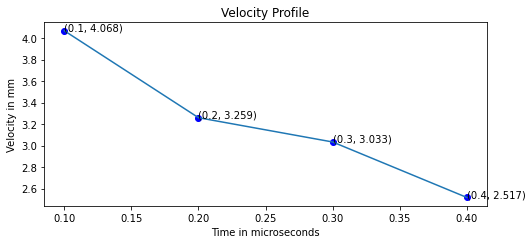

In [15]:
# plt.plot([0.01,0.2,0.3,0.4], velocity_list_mm)
plt.xlabel('Time in microseconds')
plt.ylabel('Velocity in mm')
plt.title('Velocity Profile')
plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True
time_in_micro=[0.1,0.2,0.3,0.4]
plt.plot(time_in_micro, velocity_list_mm, 'bo')
plt.plot(time_in_micro, velocity_list_mm)
for i, j in zip(time_in_micro, velocity_list_mm):
    plt.text(i, j, '({}, {})'.format(i, j))
os.chdir(r'C:\Users\Handwriting\Desktop\Dheeraj\HEMI\Main_Files\Crack_speed_evaluation\090920b_S1_IP02_07_04_2022\Crack_Velocities_090920b_S1_IP02_07_04_2022')
plt.savefig('Velocity_Crack_primary_TP_.png')
plt.show()
plt.show()

In [16]:
# Average Velocity
avg_velocity= sum(velocity_list_mm)/len(velocity_list_mm)
avg_velocity

3.2192499999999997

#### Conversion: 1 mm/1 microsecond ---> km/sec
